# **Modelo 1: Variable dependiente TASA BRUTA ESO**

## Carga de librerías

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Revisión de la Base Final 1

In [57]:
# Cargamos la Base Final 1

BaseFinal1 = pd.read_csv("../processed/BaseFinal1_clean.csv")

# Obtenemos toda la información sobre la Base para asegurarnos de que todo está correctamente para el modelo.

print("Dimensiones de la base:", BaseFinal1.shape)
print(BaseFinal1.info())

# Obtenemos el nombre de las columnas para luego ir más rápido a la hora de emplear las variables

print("Nombres de las columnas de la base:")
print(BaseFinal1.columns.tolist())

# Comprobamos el número de Comunidades Autónomas

print("Número de CCAA:", BaseFinal1["ccaa"].nunique())

# Comprobamos el número de años

print("Número de años:", BaseFinal1["year"].nunique())
print(sorted(BaseFinal1["year"].unique()))

# Comprobamos la variable de sexo

print("Categorías de sexo:", BaseFinal1["sexo"].unique())

# Comprobamos los índeces de la Base Final 1

print("Índice del panel:")
print(BaseFinal1.index.names)

# Visualizamos la Base Final 1

display(BaseFinal1)

# Observamos que la Base Final 1 presenta datos de panel con múltiples observaciones por CCAA, diferenciadas por año y sexo. 
# La variable de sexo la tenemos como categóricas pero a lo mejor más adelante necesitamos convertirla a numérica. 

Dimensiones de la base: (342, 16)
<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ccaa                          342 non-null    str    
 1   year                          342 non-null    int64  
 2   sexo                          342 non-null    str    
 3   tasa_bruta_eso                342 non-null    float64
 4   tasa_bruta_bach               342 non-null    float64
 5   tasabrutaFP_basica            342 non-null    float64
 6   tasabrutaFP_Media             342 non-null    float64
 7   tasabrutaFP_superior          342 non-null    float64
 8   pct_analfabetos               342 non-null    float64
 9   pct_educacion_primaria        342 non-null    float64
 10  pct_educacion_superior        342 non-null    float64
 11  pct_primarios_incompletos     342 non-null    float64
 12  pct_primera_etapa_secundaria  342 non-nul

,ccaa,year,sexo,tasa_bruta_eso,tasa_bruta_bach,tasabrutaFP_basica,tasabrutaFP_Media,tasabrutaFP_superior,pct_analfabetos,pct_educacion_primaria,pct_educacion_superior,pct_primarios_incompletos,pct_primera_etapa_secundaria,pct_secundaria_profesional,pct_secundaria_general,PIB_per_capita
0,Andalucia,2014,hombre,69.7,45.7,5.1375,22.0,20.6,2.625,14.950,21.125,8.825,33.650,6.950,11.875,16600.0
1,Andalucia,2014,mujer,81.8,60.0,5.1375,22.8,24.8,4.850,14.275,22.400,10.875,28.675,7.500,11.350,16600.0
2,Andalucia,2015,hombre,71.9,49.2,4.6000,22.6,22.3,2.225,14.125,21.675,9.000,33.650,6.975,12.400,17458.0
3,Andalucia,2015,mujer,83.6,63.3,1.7000,23.6,27.6,4.775,13.675,23.175,10.800,28.225,7.625,11.775,17458.0
4,Andalucia,2016,hombre,68.3,47.0,5.4000,22.5,21.5,1.925,13.350,22.325,8.700,34.250,7.075,12.375,17865.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,Pais Vasco,2020,mujer,92.2,76.3,4.2000,21.1,36.3,0.775,14.025,39.775,2.275,22.100,8.900,12.175,30115.0
338,Pais Vasco,2021,hombre,83.5,59.4,8.8000,31.4,49.7,0.350,8.325,44.450,1.700,22.850,10.275,12.100,32898.0
339,Pais Vasco,2021,mujer,90.4,76.4,3.6000,18.9,34.1,0.700,12.975,41.150,2.850,21.250,9.225,11.825,32898.0
340,Pais Vasco,2022,hombre,83.6,59.1,8.5000,31.0,46.9,0.250,7.250,44.625,1.950,22.850,10.575,12.425,36280.0


## Definición de los índices de la Base de Datos

In [58]:
# Definimos los índices porque los modelos lo requieren

BaseFinal1 = BaseFinal1.set_index(["ccaa", "year"]).sort_index()

# Comprobamos que se han definido correctamente

print("Índice del panel:")
print(BaseFinal1.index.names)



Índice del panel:
['ccaa', 'year']


## Definición de la variable objetivo

In [59]:
# Definimos la variable dependiente del modelo, en este caso será 'TASA BRUTA ESO'

y_eso = BaseFinal1["tasa_bruta_eso"]

# Visualizamos para comprobar que está correcto

print("Variable objetivo del modelo 1:")
display(y_eso.head())

Variable objetivo del modelo 1:


ccaa       year
Andalucia  2014    69.7
           2014    81.8
           2015    71.9
           2015    83.6
           2016    68.3
Name: tasa_bruta_eso, dtype: float64

## Selección de variables explicativas

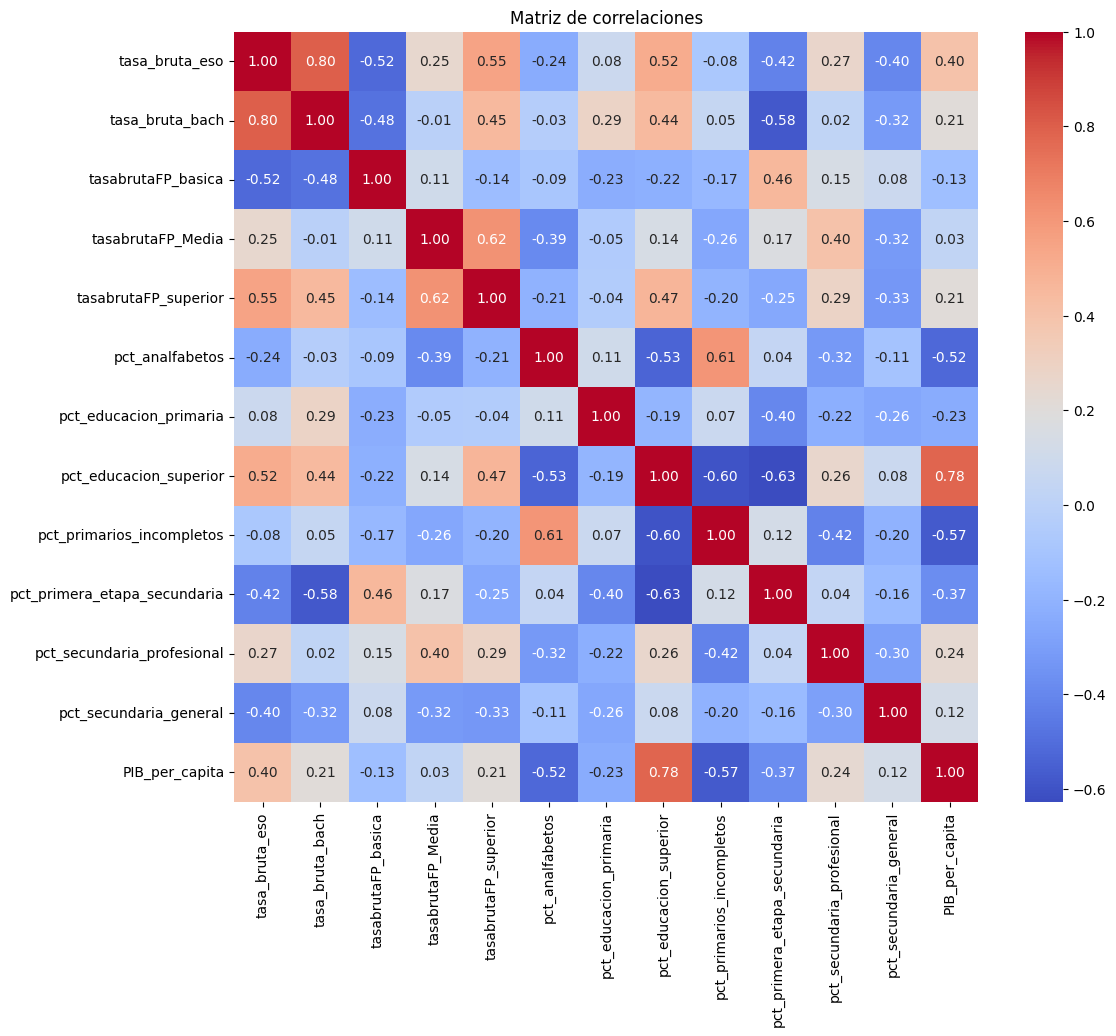

pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita    sexo  
ccaa      year                                                  
Andalucia 2014                  11.875         16600.0  hombre  
          2014                  11.350         16600.0   mujer  
          2015                  12.400         17458.0  hombre  
          2015                  11.775         17458.0   mujer  
          2016                  12.375         17865.0  hombre

Dimensiones de X_eso: (342, 9)


In [65]:
# Calculamos la matriz de correlación para poder seleccionar de manera fundamentada las variables explicativas. 

corr_matriz = BaseFinal1.corr(numeric_only=True)

# Visualizamos la matriz de correlaciones para que sea más fácil interpretarla

plt.figure(figsize=(12,10))
sns.heatmap(corr_matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()

# Tras la matriz de correlación, podemos elegir que v.explicativas vamos a emplear que no generen multicolinealidad en el modelo. 
# Por ello, estas son las variables explicativas que hemos seleccionado para este primer modelo. 

X_eso = BaseFinal1[[
    "pct_analfabetos",
    "pct_educacion_primaria",
    "pct_educacion_superior",
    "pct_primarios_incompletos",
    "pct_primera_etapa_secundaria",
    "pct_secundaria_profesional",
    "pct_secundaria_general",
    "PIB_per_capita",
    "sexo"
]]

# Visualizamos las v.explicativas

display(X_eso.head())
print("Dimensiones de X_eso:", X_eso.shape)

## Tratamiento de la variable categórica 'Sexo'

In [68]:
# Una vez hecho esto elegidas las v.explicativas, tenemos que transformar la variable 'sexo'

X_eso = BaseFinal1[[
    "pct_analfabetos",
    "pct_educacion_primaria",
    "pct_educacion_superior",
    "pct_primarios_incompletos",
    "pct_primera_etapa_secundaria",
    "pct_secundaria_profesional",
    "pct_secundaria_general",
    "PIB_per_capita",
    "sexo"
]].copy()

# Transformamos sexo en variable dummy/binaria                            # hombre = 0, mujer = 1

X_eso["sexo_transformacion"] = X_eso["sexo"].map({"hombre": 0, "mujer": 1})

# Comprobamos que la transformación se ha hecho correctamente

display(X_eso[["sexo", "sexo_transformacion"]].head())

# Revisamos si hay nulos tras la transformación

print("Nulos en sexo_transformacion:", X_eso["sexo_transformacion"].isnull().sum())

# Eliminamos la columna original

X_eso = X_eso.drop(columns=["sexo"])

# Comprobamos el resultado final

display(X_eso.head())
print("Dimensiones de X_eso:", X_eso.shape)

sexo  sexo_transformacion
ccaa      year                             
Andalucia 2014  hombre                    0
          2014   mujer                    1
          2015  hombre                    0
          2015   mujer                    1
          2016  hombre                    0

Nulos en sexo_transformacion: 0


pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita  sexo_transformacion  
ccaa      year                                                               
Andalucia 2014                  11.875         16600.0                    0  
          2014                  11.350         16600.0                    1  
          2015                  12.400         17458.0                    0  
          2015                  11.775         17458.0                    1  
          2016                  12.375         17865.0                    0

Dimensiones de X_eso: (342, 9)


## Construcción final de la matriz del modelo 1

In [69]:
# Añadimos constante para el modelo econométrico porque va a recoger el nivel base de la v.dependiente cuando el resto de variables tomen valor 0.

X_eso_model = sm.add_constant(X_eso)

# Comprobamos dimensiones

print("Dimensiones de X_eso:", X_eso_model.shape)
print("Dimensiones de y_eso:", y_eso.shape)

# Visualizamos la estructura para ver que sea la correcta

display(X_eso_model.head())
display(y_eso.head())

Dimensiones de X_eso: (342, 10)
Dimensiones de y_eso: (342,)


const  pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                                   
Andalucia 2014    1.0            2.625                  14.950   
          2014    1.0            4.850                  14.275   
          2015    1.0            2.225                  14.125   
          2015    1.0            4.775                  13.675   
          2016    1.0            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita  sexo_transformacion  
ccaa      year                                                               
Andalucia 2014                  11.875         16600.0                    0  
          2014                  11.350         16600.0                    1  
          2015                  12.400         17458.0                    0  
          2015                  11.775         17458.0                    1  
          2016                  12.375         17865.0                    0

ccaa       year
Andalucia  2014    69.7
           2014    81.8
           2015    71.9
           2015    83.6
           2016    68.3
Name: tasa_bruta_eso, dtype: float64

## Estimación del modelo Mínimos Cuadrados Ordinarios Agrupados 'Pooled OLS'

In [70]:
# Estimamos el modelo Mínimos Cuadrados Ordinarios Agrupados (MCO)

MCO_model = PooledOLS(y_eso, X_eso_model)
MCO_results = MCO_model.fit()

# Obtenemos los resultados

print(MCO_results.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:         tasa_bruta_eso   R-squared:                        0.6913
Estimator:                  PooledOLS   R-squared (Between):              0.7600
No. Observations:                 342   R-squared (Within):               0.6037
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.6913
Time:                        18:16:43   Log-likelihood                   -1042.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      82.595
Entities:                          19   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                   F(9,332)
Min Obs:                       18.000                                           
Max Obs:                       18.000   F-statistic (robust):             82.595
                            

## Estimación del modelo de efectos fijos

In [71]:
# Estimamos el modelo de efectos fijos

EF_model = PanelOLS(y_eso, X_eso_model, entity_effects=True)
EF_results = EF_model.fit()

# Obtenemos los resultados

print(EF_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         tasa_bruta_eso   R-squared:                        0.6917
Estimator:                   PanelOLS   R-squared (Between):              0.2962
No. Observations:                 342   R-squared (Within):               0.6917
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.4702
Time:                        18:21:03   Log-likelihood                   -901.59
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      78.260
Entities:                          19   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                   F(9,314)
Min Obs:                       18.000                                           
Max Obs:                       18.000   F-statistic (robust):             78.260
                            